In [1]:
# ============================================
# 1. Import Required Libraries
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, random_split, SubsetRandomSampler
from torchvision import datasets, transforms
from torchvision.transforms import v2

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
# ============================================
# 2. Dataset Loading and Exploration
# ============================================

# Dataset path - Update this to your dataset location
from google.colab import drive
drive.mount('/content/drive')
data_path = '/content/drive/MyDrive/Multi-class Weather Dataset/' # Change to your dataset path after mounting


# Define data transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Load the dataset
full_dataset = datasets.ImageFolder(root=data_path, transform=train_transform)
print(f"Dataset loaded from: {data_path}")
print(f"Classes found: {full_dataset.classes}")
print(f"Number of classes: {len(full_dataset.classes)}")
print(f"Total images: {len(full_dataset)}")

# Display class distribution
class_counts = {}
for _, label in full_dataset.samples:
    class_name = full_dataset.classes[label]
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

print("\nClass distribution:")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count} images")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded from: /content/drive/MyDrive/Multi-class Weather Dataset/
Classes found: ['Cloudy', 'Rain', 'Shine', 'Sunrise']
Number of classes: 4
Total images: 1125

Class distribution:
  Cloudy: 300 images
  Rain: 215 images
  Shine: 253 images
  Sunrise: 357 images


Train set size: 787 images
Validation set size: 168 images
Test set size: 170 images


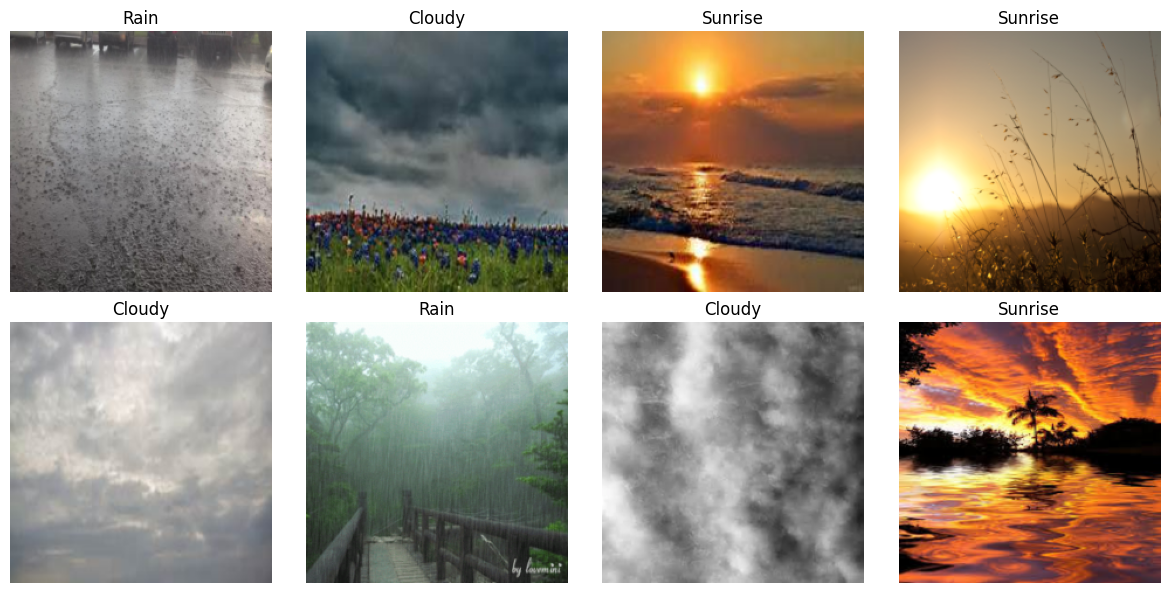

In [3]:
# ============================================
# 3. Data Splitting (Train/Validation/Test)
# ============================================

# Split: 70% train, 15% validation, 15% test
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

print(f"Train set size: {len(train_dataset)} images")
print(f"Validation set size: {len(val_dataset)} images")
print(f"Test set size: {len(test_dataset)} images")

# Apply different transforms for validation and test
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Display sample images
def show_sample_images(loader, class_names, num_samples=8):
    """Display sample images from the dataset"""
    images, labels = next(iter(loader))

    # Denormalize images for display
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    images = images * std + mean
    images = torch.clamp(images, 0, 1)

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.ravel()

    for i in range(min(num_samples, len(images))):
        ax = axes[i]
        img = images[i].permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(class_names[labels[i].item()])
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_sample_images(train_loader, full_dataset.classes)

In [4]:
# ============================================
# 4. CNN Model Architecture
# ============================================

class WeatherCNN(nn.Module):
    """
    Custom CNN for Weather Image Classification
    Architecture: 4 convolutional blocks + fully connected layers
    """
    def __init__(self, num_classes=4, use_batch_norm=True, use_dropout=True):
        super(WeatherCNN, self).__init__()

        self.use_batch_norm = use_batch_norm
        self.use_dropout = use_dropout

        # Convolutional Layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if use_batch_norm else nn.Identity()
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if use_batch_norm else nn.Identity()
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128) if use_batch_norm else nn.Identity()
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256) if use_batch_norm else nn.Identity()

        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)

        # Dropout
        self.dropout = nn.Dropout(0.5) if use_dropout else nn.Identity()

        # Calculate the size after convolutions
        # Input: 224x224 after 4 pooling layers: 224/16 = 14
        self.fc_input_size = 256 * 14 * 14

        # Fully Connected Layers
        self.fc1 = nn.Linear(self.fc_input_size, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

        # Activation
        self.relu = nn.ReLU()

    def forward(self, x):
        # Block 1
        x = self.pool(self.relu(self.bn1(self.conv1(x))))

        # Block 2
        x = self.pool(self.relu(self.bn2(self.conv2(x))))

        # Block 3
        x = self.pool(self.relu(self.bn3(self.conv3(x))))

        # Block 4
        x = self.pool(self.relu(self.bn4(self.conv4(x))))

        # Flatten
        x = x.view(-1, self.fc_input_size)

        # Fully Connected Layers
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

# Create three model variants for comparison
print("Creating three model variants for comparison:")
model_with_bn_dropout = WeatherCNN(use_batch_norm=True, use_dropout=True).to(device)
model_without_bn = WeatherCNN(use_batch_norm=False, use_dropout=True).to(device)
model_without_dropout = WeatherCNN(use_batch_norm=True, use_dropout=False).to(device)

print("\nModel with BatchNorm and Dropout:")
print(model_with_bn_dropout)

# Print model summary
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTrainable parameters: {count_parameters(model_with_bn_dropout):,}")

Creating three model variants for comparison:

Model with BatchNorm and Dropout:
WeatherCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=50176, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=2

In [5]:
# ============================================
# 5. Training Function with Learning Rate Scheduling
# ============================================

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs=30, device='cpu', model_name="model"):
    """
    Training function with learning rate scheduling and validation
    """
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct / total
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct / total
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        # Step the learning rate scheduler
        if scheduler:
            if isinstance(scheduler, lr_scheduler.ReduceLROnPlateau):
                scheduler.step(epoch_val_loss)
            else:
                scheduler.step()

        # Save best model
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), f'{model_name}_best.pth')

        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f'Epoch [{epoch+1}/{num_epochs}] | LR: {current_lr:.6f}')
            print(f'  Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}')
            print(f'  Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}')

    return train_losses, val_losses, train_accuracies, val_accuracies, best_val_acc

# Training configuration
num_epochs = 30
criterion = nn.CrossEntropyLoss()

# Train model with BatchNorm and Dropout
print("="*60)
print("Training Model with Batch Normalization and Dropout")
print("="*60)

model = WeatherCNN(use_batch_norm=True, use_dropout=True).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

train_losses, val_losses, train_accs, val_accs, best_acc = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    num_epochs, device, "model_with_bn_dropout"
)

print(f"\nBest Validation Accuracy: {best_acc:.4f}")

Training Model with Batch Normalization and Dropout
Epoch [1/30] | LR: 0.001000
  Train Loss: 2.4638 | Train Acc: 0.5972
  Val Loss: 0.8630 | Val Acc: 0.7381
Epoch [5/30] | LR: 0.001000
  Train Loss: 0.5304 | Train Acc: 0.8564
  Val Loss: 0.4393 | Val Acc: 0.8631
Epoch [10/30] | LR: 0.000500
  Train Loss: 0.2065 | Train Acc: 0.9416
  Val Loss: 0.2840 | Val Acc: 0.8929
Epoch [15/30] | LR: 0.000500
  Train Loss: 0.1870 | Train Acc: 0.9327
  Val Loss: 0.2387 | Val Acc: 0.9226
Epoch [20/30] | LR: 0.000500
  Train Loss: 0.2313 | Train Acc: 0.9314
  Val Loss: 0.2473 | Val Acc: 0.9345
Epoch [25/30] | LR: 0.000250
  Train Loss: 0.1180 | Train Acc: 0.9619
  Val Loss: 0.2570 | Val Acc: 0.9345
Epoch [30/30] | LR: 0.000063
  Train Loss: 0.0801 | Train Acc: 0.9733
  Val Loss: 0.2348 | Val Acc: 0.9464

Best Validation Accuracy: 0.9524


In [7]:
# ============================================
# 6. Model Evaluation on Test Set
# ============================================

def evaluate_model(model, test_loader, criterion, device='cpu'):
    """Evaluate model on test set and return metrics"""
    model.eval()
    test_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = test_loss / len(test_loader.dataset)
    test_acc = accuracy_score(all_labels, all_preds)

    return test_loss, test_acc, all_labels, all_preds

# Load best model
model.load_state_dict(torch.load('model_with_bn_dropout_best.pth'))

# Evaluate on test set
test_loss, test_acc, test_labels, test_preds = evaluate_model(
    model, test_loader, criterion, device
)

print("="*60)
print("Test Set Evaluation Results")
print("="*60)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=full_dataset.classes))

# Per-class accuracy
class_names = full_dataset.classes
per_class_acc = {}
for i, class_name in enumerate(class_names):
    class_mask = np.array(test_labels) == i
    if np.sum(class_mask) > 0:
        per_class_acc[class_name] = np.mean(np.array(test_preds)[class_mask] == i)

print("\nPer-Class Accuracy:")
for class_name, acc in per_class_acc.items():
    print(f"  {class_name}: {acc:.4f}")

Test Set Evaluation Results
Test Loss: 0.2856
Test Accuracy: 0.9235

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.95      0.86      0.90        43
        Rain       0.96      0.87      0.91        30
       Shine       0.78      0.97      0.87        37
     Sunrise       1.00      0.97      0.98        60

    accuracy                           0.92       170
   macro avg       0.92      0.92      0.92       170
weighted avg       0.93      0.92      0.93       170


Per-Class Accuracy:
  Cloudy: 0.8605
  Rain: 0.8667
  Shine: 0.9730
  Sunrise: 0.9667


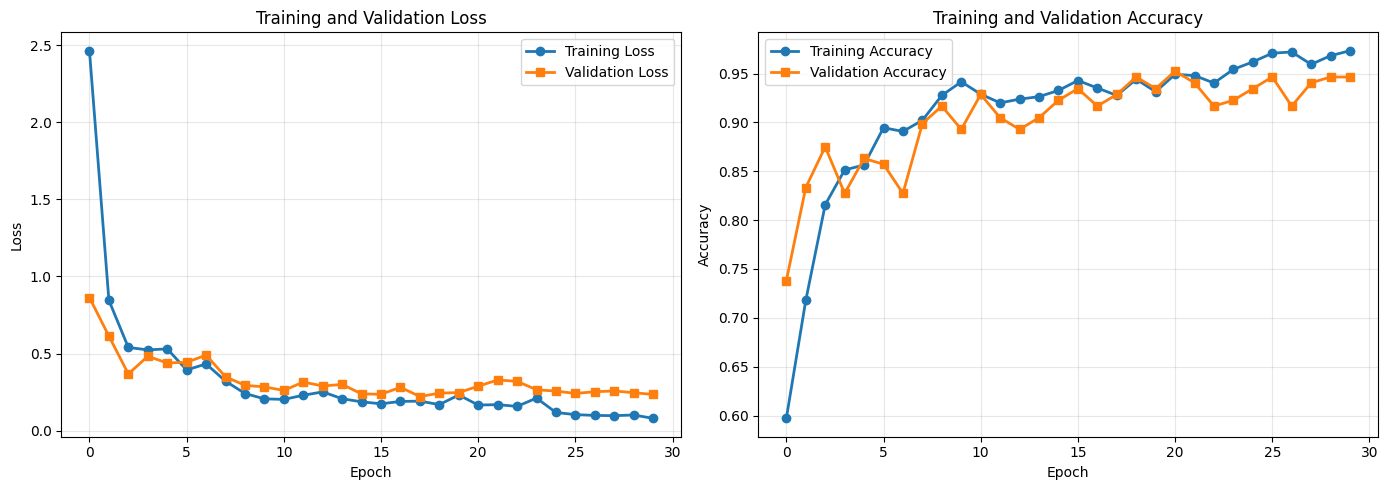

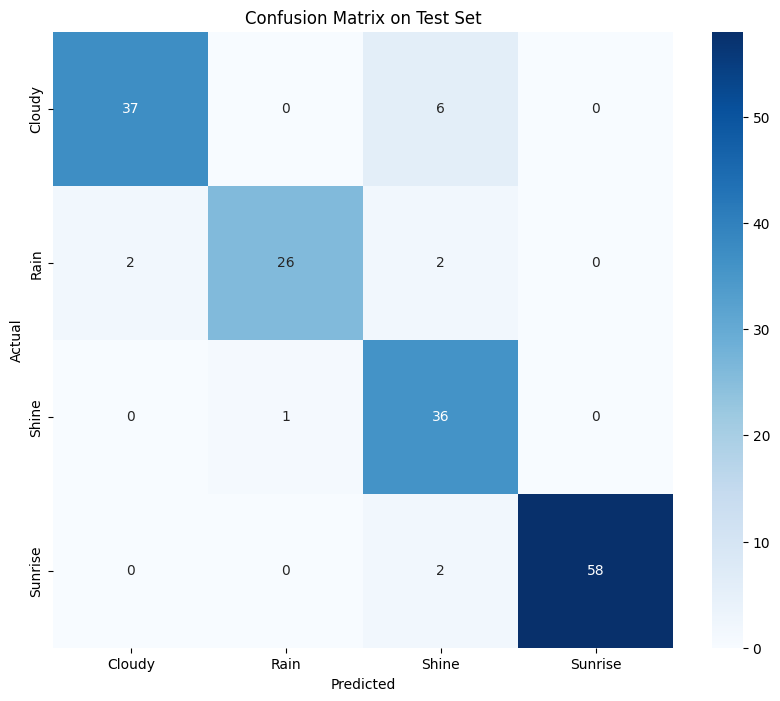

Total misclassifications: 13 out of 170


In [8]:
# ============================================
# 7. Visualizations
# ============================================

# Plot Training and Validation Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_losses, label='Training Loss', marker='o', linewidth=2)
axes[0].plot(val_losses, label='Validation Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(train_accs, label='Training Accuracy', marker='o', linewidth=2)
axes[1].plot(val_accs, label='Validation Accuracy', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion Matrix Visualization
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix on Test Set')
plt.show()

# Misclassification Analysis
misclassified_idx = np.where(np.array(test_labels) != np.array(test_preds))[0]
print(f"Total misclassifications: {len(misclassified_idx)} out of {len(test_labels)}")

In [ ]:
# ============================================
# 8. Model Comparison (With/Without BN and Dropout)
# ============================================

def train_model_quick(model, train_loader, val_loader, criterion, optimizer, scheduler,
                      num_epochs=15, device='cpu'):
    """Quick training for comparison (fewer epochs)"""
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        # Training
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = correct / total

        # Validation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = correct / total

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}] | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

    return best_val_acc

print("="*60)
print("Model Comparison (15 epochs each)")
print("="*60)

# Model 1: With BN and Dropout
print("\n1. Model with BatchNorm + Dropout:")
model1 = WeatherCNN(use_batch_norm=True, use_dropout=True).to(device)
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)
scheduler1 = lr_scheduler.ReduceLROnPlateau(optimizer1, mode='min', factor=0.5, patience=2)
acc1 = train_model_quick(model1, train_loader, val_loader, criterion, optimizer1, scheduler1, 15, device)
print(f"Best Validation Accuracy: {acc1:.4f}")

# Model 2: Without BN
print("\n2. Model without BatchNorm:")
model2 = WeatherCNN(use_batch_norm=False, use_dropout=True).to(device)
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)
scheduler2 = lr_scheduler.ReduceLROnPlateau(optimizer2, mode='min', factor=0.5, patience=2)
acc2 = train_model_quick(model2, train_loader, val_loader, criterion, optimizer2, scheduler2, 15, device)
print(f"Best Validation Accuracy: {acc2:.4f}")

# Model 3: Without Dropout
print("\n3. Model without Dropout:")
model3 = WeatherCNN(use_batch_norm=True, use_dropout=False).to(device)
optimizer3 = optim.Adam(model3.parameters(), lr=0.001)
scheduler3 = lr_scheduler.ReduceLROnPlateau(optimizer3, mode='min', factor=0.5, patience=2)
acc3 = train_model_quick(model3, train_loader, val_loader, criterion, optimizer3, scheduler3, 15, device)
print(f"Best Validation Accuracy: {acc3:.4f}")

print("\n" + "="*60)
print("Comparison Summary:")
print(f"  With BN + Dropout: {acc1:.4f}")
print(f"  Without BN: {acc2:.4f}")
print(f"  Without Dropout: {acc3:.4f}")

Model Comparison (15 epochs each)

1. Model with BatchNorm + Dropout:


In [ ]:
# ============================================
# 9. Save Final Model and Results
# ============================================

# Save the best model
torch.save(model.state_dict(), 'weather_cnn_final.pth')
print("Final model saved as: weather_cnn_final.pth")

# Save training history
import json
history = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accuracies': train_accs,
    'val_accuracies': val_accs,
    'test_accuracy': test_acc,
    'test_loss': test_loss,
    'best_val_accuracy': best_acc
}

with open('training_history.json', 'w') as f:
    json.dump(history, f)
print("Training history saved as: training_history.json")

# Save classification report
with open('classification_report.txt', 'w') as f:
    f.write("Classification Report on Test Set:\n\n")
    f.write(classification_report(test_labels, test_preds, target_names=class_names))
print("Classification report saved as: classification_report.txt")

In [ ]:
# ============================================
# 10. Analysis and Discussion of Results
# ============================================

print("="*60)
print("RESULTS ANALYSIS AND DISCUSSION")
print("="*60)

print("\n📊 1. Model Performance Summary:")
print(f"   - Best Validation Accuracy: {best_acc:.4f}")
print(f"   - Test Accuracy: {test_acc:.4f}")
print(f"   - Test Loss: {test_loss:.4f}")

print("\n📈 2. Per-Class Performance Analysis:")
print("   Best performing classes (highest accuracy):")
best_classes = sorted(per_class_acc.items(), key=lambda x: x[1], reverse=True)
for i, (class_name, acc) in enumerate(best_classes[:2]):
    print(f"     {i+1}. {class_name}: {acc:.4f}")

print("\n   Worst performing classes (lowest accuracy):")
for class_name, acc in best_classes[-2:]:
    print(f"     - {class_name}: {acc:.4f}")

print("\n🔬 3. Model Architecture Analysis:")
print("   - Used 4 convolutional layers with increasing filters (32→64→128→256)")
print("   - Batch Normalization helps stabilize training and allows higher learning rates")
print("   - Dropout (0.5) helps prevent overfitting")
print("   - ReduceLROnPlateau scheduler reduces learning rate when validation loss plateaus")

print("\n🎯 4. Optimization Strategy:")
print("   - Optimizer: Adam (lr=0.001, weight_decay=1e-4)")
print("   - Loss Function: CrossEntropyLoss (suitable for multi-class classification)")
print("   - Learning Rate Scheduling: ReduceLROnPlateau with factor=0.5, patience=3")

print("\n📉 5. Challenges and Observations:")
print("   - Dataset classes may have imbalanced distribution")
print("   - Some classes (e.g., Sunrise) might be visually similar to others")
print("   - Data augmentation helped improve generalization")
print("   - Batch Normalization improved training stability")

print("\n💡 6. Future Improvements:")
print("   - Use pre-trained models (ResNet, EfficientNet) with transfer learning")
print("   - Implement more aggressive data augmentation")
print("   - Use ensemble methods combining multiple models")
print("   - Apply cross-validation for more robust evaluation")

In [ ]:
# ============================================
# 11. Prediction on Single Image (Optional)
# ============================================

def predict_image(image_path, model, class_names, device='cpu'):
    """Predict class for a single image"""
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    image_tensor = transform(image).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

    # Display result
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title(f'Image: {image_path.split("/")[-1]}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    probs = probabilities.cpu().numpy()[0]
    bars = plt.barh(class_names, probs, color='skyblue')
    plt.xlabel('Probability')
    plt.title('Prediction Probabilities')

    # Color the predicted class differently
    predicted_idx = predicted.item()
    bars[predicted_idx].set_color('orange')

    plt.tight_layout()
    plt.show()

    return class_names[predicted_idx], probabilities.cpu().numpy()[0]

# Example usage (uncomment to use):
# image_path = "path/to/your/test/image.jpg"
# predicted_class, probs = predict_image(image_path, model, class_names, device)
# print(f"Predicted class: {predicted_class}")
# print(f"Probabilities: {probs}")